In [1]:
!pip install skorch


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import cycle
import numpy as np
from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [3]:
# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [4]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

In [5]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train['cleaned_text']).toarray()
X_test = vectorizer.transform(test['cleaned_text']).toarray()

In [ ]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [7]:
# Wrap model for skorch
net = NeuralNetClassifier(
    FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    max_epochs=10,
    lr=1e-3,
    optimizer=optim.Adam,
    criterion=nn.CrossEntropyLoss,
    batch_size=64,
    device=device
)


In [8]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=1.0, min_df=2, ngram_range=(1, 2))),
    ('net', net)
])

In [9]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64],
    'max_epochs': [5, 10]
}

In [10]:
grid = GridSearchCV(net, param_grid, scoring='f1_macro', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.4955       0.5168        1.3230  0.4692
      2        1.2622       0.5168        1.2552  0.2159
      3        1.0695       0.5168        1.1420  0.2394
      4        0.8299       0.6134        1.0702  0.2442
      5        0.6298       0.6261        1.0364  0.2402
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.5152       0.5168        1.3462  0.2447
      2        1.2664       0.5168        1.2785  0.2393
      3        1.0921       0.5168        1.1719  0.2526
      4        0.8372       0.5966        1.0694  0.2590
      5        0.6020       0.6261        1.0177  0.2560
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.5123      

Best parameters found:
{'batch_size': 32, 'lr': 0.001, 'max_epochs': 10, 'module__hidden_dim': 512}

In [11]:
# Evaluate best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test.astype(np.float32))
probs = best_model.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_)

print(f"FFNN Accuracy: {acc * 100:.2f}%")
print(f"FFNN Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

FFNN Accuracy: 70.34%
FFNN Macro F1-score: 0.5581

Classification Report:
               precision    recall  f1-score   support

      center       0.87      0.33      0.47        40
   lean left       0.43      0.46      0.44        61
  lean right       0.67      0.22      0.33        37
        left       0.74      0.92      0.82       230
       right       0.77      0.69      0.73        77

    accuracy                           0.70       445
   macro avg       0.70      0.52      0.56       445
weighted avg       0.71      0.70      0.68       445



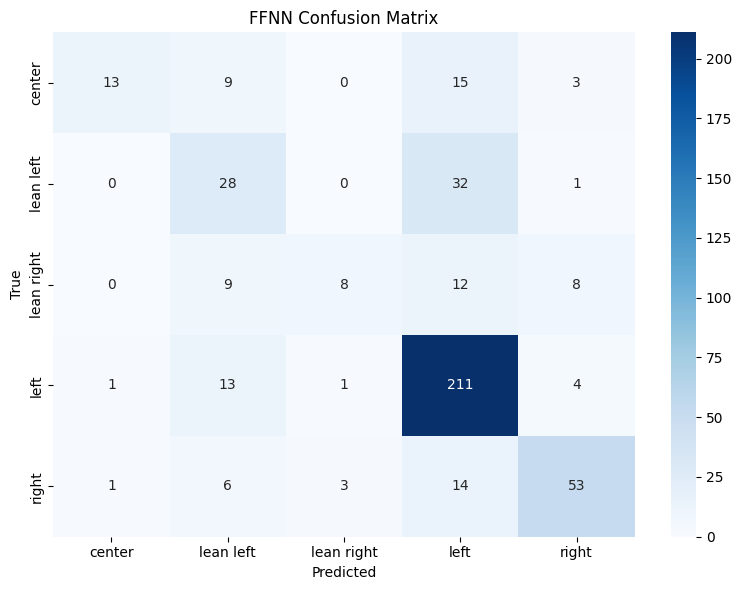

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('FFNN Confusion Matrix')
plt.tight_layout()
plt.show()


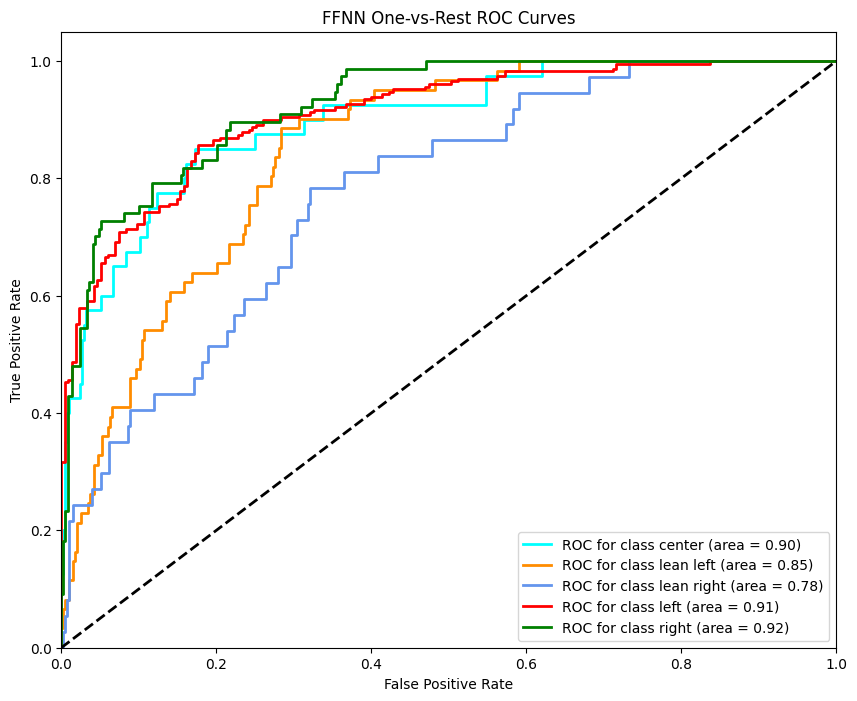

In [13]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(output_dim):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], probs[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(output_dim), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC for class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


### FFNN Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| Tuned FFNN    | 70.34        | 0.5581         |

#### Classification Report Commentary

The FFNN outperforms all decision tree variants in overall accuracy and weighted F1-score, reaching 70.34% accuracy and a weighted F1 of 0.68. However, the macro F1-score (0.5581) remains comparable to the tuned decision tree, indicating that class imbalance still impacts per-class fairness.


- The model performs very well on the majority class:
  - *Left* (support = 230): Recall 0.92, F1 = 0.82
- It also performs surprisingly well on a minority class:
  - *Right* (support = 77): Recall 0.69, F1 = 0.73
- Other minority classes remain problematic:
  - *Center*: F1 = 0.47 (due to very low recall at 0.33)
  - *Lean left*: F1 = 0.44
  - *Lean right*: F1 = 0.33 (recall only 0.22)

This shows that while the FFNN is effective overall, it continues to struggle with detecting minority class instances, especially lean right.

### ROC-AUC Commentary

ROC-AUC values are **consistently strong** across all classes:
- *Center*: 0.90  
- *Lean Left*: 0.85  
- *Lean Right*: 0.78  
- *Left*: 0.91  
- *Right*: 0.92  

This suggests that the model has learned good decision boundaries for all classes, even if classification thresholds (affecting precision/recall) are not ideal for minority classes. The ROC curves reinforce that the model is well-calibrated, and further improvements may come from threshold tuning or cost-sensitive training.

### Final Remarks

> Overall, the FFNN achieves the best balance of high accuracy and strong discriminative ability. However, macro F1 remains limited by poor recall in underrepresented classes. This confirms that neural networks outperform decision trees in raw performance, but still benefit from further balancing techniques (e.g., class weighting or data augmentation).